<a href="https://colab.research.google.com/github/MARIAHUSSAIN123/fire-smoke-live/blob/main/Fire_Smoke_Detection_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔥 Fire & Smoke Detection using Deep Learning (Transfer Learning)
### Mid-Term Final Project — v3 (3-class: fire / smoke / normal)

**Domain:** Computer Vision / Transfer Learning
**Goal:** Build an end-to-end image classification system that detects **fire**, **smoke**, or **normal (neither)** scenes, and deploy it with a live Gradio demo — all inside Google Colab.

**Why v3?** v2 was binary (fire vs non-fire) and had two problems: (1) there was no dedicated smoke class, so real smoke images got forced into "fire" or "non-fire", and (2) the non-fire class was small and narrow (mostly outdoor nature scenes), so anything visually different — like a cat or an indoor photo — also got predicted as fire. v3 fixes both by switching to a dataset that has three properly separated, balanced classes: **Fire**, **Smoke**, and **Normal**.

**Why Transfer Learning?** Training a CNN from scratch needs thousands of images and many hours to reach good accuracy. Transfer learning reuses a model (MobileNetV2) already trained on 1.4M+ images (ImageNet), so we get high accuracy in a few minutes of training on Colab's free GPU.

**⚠️ Run every cell top to bottom, in order, without skipping.**

**How this notebook maps to the syllabus:**
| Module | Where it shows up here |
|---|---|
| 1. Python | Whole notebook (functions, loops, OOP via Keras) |
| 2. Statistics & Probability | Class distribution, train/val/test split ratios, confusion matrix, precision/recall |
| 3. Data Analytics & Visualization | EDA, sample grids, accuracy/loss curves, confusion matrix heatmap |
| 4. Machine Learning (Supervised) | Multi-class classification problem, train/test evaluation |
| 5. Deep Learning / CV / Transfer Learning | Baseline CNN (from scratch) vs MobileNetV2 (transfer learning) |
| 6. NLP | Not applicable to this domain — noted for completeness |

---


## 1️⃣ Setup & Imports
Run this first. In Colab: **Runtime → Change runtime type → T4 GPU**.

In [4]:
!pip install -q datasets huggingface_hub gradio

import os, shutil, pathlib, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2️⃣ Dataset Download — Fire / Smoke / Normal (3 classes, already balanced)

We use **`EdBianchi/SmokeFire`** (Hugging Face) instead of the old binary Kaggle "FIRE Dataset". It's built from two Kaggle sources (`kutaykutlu/forest-fire` and `mohnishsaiprasad/forest-fire-images`) and already gives us three separate, balanced classes:

- **Fire** — 2525 images
- **Smoke** — 2525 images
- **Normal** — 2525 images (varied everyday/nature scenes — this is what teaches the model what "not fire, not smoke" looks like)

Pre-split into train (6060) / validation (756) / test (759), total ~891 MB — much lighter than the old 6.4 GB Kaggle download, and no Kaggle API key needed at all.


In [5]:
from datasets import load_dataset

hf_dataset = load_dataset("EdBianchi/SmokeFire")
print(hf_dataset)

label_names = hf_dataset["train"].features["label"].names
print("Classes:", label_names)


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 6060
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 756
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 759
    })
})
Classes: ['Fire', 'Normal', 'Smoke']


### Export the Hugging Face dataset to a normal folder structure

The rest of this notebook uses `image_dataset_from_directory` (same as v2), so we write each split out to disk as `class_name/image.jpg` folders once. This only needs to run once per Colab session.


In [6]:
DATA_ROOT = pathlib.Path("/content/smokefire_data")
if DATA_ROOT.exists():
    shutil.rmtree(DATA_ROOT)

split_map = {"train": "train", "validation": "val", "test": "test"}

for hf_split, folder_name in split_map.items():
    split_ds = hf_dataset[hf_split]
    for i, example in enumerate(split_ds):
        label_name = label_names[example["label"]]
        out_dir = DATA_ROOT / folder_name / label_name
        out_dir.mkdir(parents=True, exist_ok=True)
        img = example["image"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img.save(out_dir / f"{i}.jpg", quality=95)

print("Export done. Folder structure:")
for split_dir in sorted(DATA_ROOT.iterdir()):
    counts = {d.name: len(list(d.glob("*.jpg"))) for d in split_dir.iterdir() if d.is_dir()}
    print(f"  {split_dir.name}: {counts}")

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"


Export done. Folder structure:
  test: {'Fire': 253, 'Normal': 253, 'Smoke': 253}
  train: {'Fire': 2020, 'Normal': 2020, 'Smoke': 2020}
  val: {'Fire': 252, 'Normal': 252, 'Smoke': 252}


In [7]:
# 🩹 Fix: diversify the "Normal" class so the model doesn't just learn
# "forest fire vs forest non-fire" — it needs to see non-fire, non-smoke
# everyday scenes too (animals, indoor objects, vehicles, etc.)

from datasets import load_dataset

print("Downloading diverse images to strengthen the 'Normal' class...")

# Source 1: real pet/animal photos — this directly fixes the cat-predicted-as-fire case
cats_dogs = load_dataset("microsoft/cats_vs_dogs", split="train")
cats_dogs = cats_dogs.shuffle(seed=SEED)

# Source 2: broad everyday objects/scenes (furniture, vehicles, people, trees, buildings...)
cifar = load_dataset("uoft-cs/cifar100", split="train")
cifar = cifar.shuffle(seed=SEED)

# Roughly matches the existing per-class size so Normal doesn't dominate too much
EXTRA_COUNTS = {"train": 2000, "val": 250, "test": 250}

def save_extra_images(dataset, image_key, start_idx, count, out_dir):
    saved, idx = 0, start_idx
    while saved < count and idx < len(dataset):
        try:
            img = dataset[idx][image_key]
            if img.mode != "RGB":
                img = img.convert("RGB")
            img.save(out_dir / f"extra_{idx}.jpg", quality=95)
            saved += 1
        except Exception:
            pass
        idx += 1
    return idx

cd_idx, cf_idx = 0, 0
for split, count in EXTRA_COUNTS.items():
    out_dir = DATA_ROOT / split / "normal"
    out_dir.mkdir(parents=True, exist_ok=True)
    half = count // 2
    cd_idx = save_extra_images(cats_dogs, "image", cd_idx, half, out_dir)
    cf_idx = save_extra_images(cifar, "img", cf_idx, count - half, out_dir)

print("Done. Updated folder structure:")
for split_dir in sorted(DATA_ROOT.iterdir()):
    counts = {d.name: len(list(d.glob("*.jpg"))) for d in split_dir.iterdir() if d.is_dir()}
    print(f"  {split_dir.name}: {counts}")

Done. Updated folder structure:
  test: {'Fire': 253, 'Normal': 253, 'normal': 125, 'Smoke': 253}
  train: {'Fire': 2020, 'Normal': 2020, 'normal': 1000, 'Smoke': 2020}
  val: {'Fire': 252, 'Normal': 252, 'normal': 125, 'Smoke': 252}


In [8]:
# Fix case mismatch: merge lowercase "normal" into "Normal"
for split in ["train", "val", "test"]:
    wrong_dir = DATA_ROOT / split / "normal"
    correct_dir = DATA_ROOT / split / "Normal"
    if wrong_dir.exists():
        correct_dir.mkdir(parents=True, exist_ok=True)
        for f in wrong_dir.glob("*.jpg"):
            f.rename(correct_dir / f.name)
        wrong_dir.rmdir()

print("Fixed. Updated folder structure:")
for split_dir in sorted(DATA_ROOT.iterdir()):
    counts = {d.name: len(list(d.glob("*.jpg"))) for d in split_dir.iterdir() if d.is_dir()}
    print(f"  {split_dir.name}: {counts}")

Fixed. Updated folder structure:
  test: {'Fire': 253, 'Normal': 378, 'Smoke': 253}
  train: {'Fire': 2020, 'Normal': 3020, 'Smoke': 2020}
  val: {'Fire': 252, 'Normal': 377, 'Smoke': 252}


In [9]:
# 🩹 Diversify Fire & Smoke classes with studio-style / isolated-background images
# (black background, stock-photo style — the kind of images the original
# forest-fire dataset does NOT contain, which is why the model fails on them)

import requests
from PIL import Image
from io import BytesIO

PEXELS_API_KEY = "AXh2aQCbvj5KbYbFhvhtGcp6uVwAanl2DBsitvo2SbNfvpaTegjBNS4T"  # <-- yahan apni key paste karein
HEADERS = {"Authorization": PEXELS_API_KEY}

def download_pexels_images(query, out_dir, count, start_index=0):
    """Search Pexels for `query` and save `count` photos into out_dir."""
    out_dir.mkdir(parents=True, exist_ok=True)
    saved = 0
    page = 1
    idx = start_index
    while saved < count and page <= 20:  # Pexels max 80/page, we page through
        resp = requests.get(
            "https://api.pexels.com/v1/search",
            headers=HEADERS,
            params={"query": query, "per_page": 80, "page": page},
        )
        if resp.status_code != 200:
            print(f"  ⚠️ Pexels API error {resp.status_code} for query '{query}'")
            break
        data = resp.json()
        photos = data.get("photos", [])
        if not photos:
            break
        for photo in photos:
            if saved >= count:
                break
            try:
                img_url = photo["src"]["large"]
                img_resp = requests.get(img_url, timeout=10)
                img = Image.open(BytesIO(img_resp.content)).convert("RGB")
                img.save(out_dir / f"pexels_{query.replace(' ', '_')}_{idx}.jpg", quality=95)
                saved += 1
                idx += 1
            except Exception as e:
                pass
        page += 1
    print(f"  Saved {saved} images for query '{query}' -> {out_dir}")
    return idx

# Queries chosen to specifically cover the studio/isolated-background style
FIRE_QUERIES = ["fire flame black background", "flame isolated", "fire on black background"]
SMOKE_QUERIES = ["smoke black background", "smoke isolated", "white smoke texture"]

# Roughly 15% extra on top of existing counts, split across splits
EXTRA_COUNTS = {"train": 300, "val": 40, "test": 40}

for split, total_count in EXTRA_COUNTS.items():
    print(f"\n--- {split} split ---")

    fire_dir = DATA_ROOT / split / "Fire"
    smoke_dir = DATA_ROOT / split / "Smoke"

    per_query_fire = total_count // len(FIRE_QUERIES)
    per_query_smoke = total_count // len(SMOKE_QUERIES)

    idx = 0
    for q in FIRE_QUERIES:
        idx = download_pexels_images(q, fire_dir, per_query_fire, start_index=idx)

    idx = 0
    for q in SMOKE_QUERIES:
        idx = download_pexels_images(q, smoke_dir, per_query_smoke, start_index=idx)

print("\nDone. Updated folder structure:")
for split_dir in sorted(DATA_ROOT.iterdir()):
    counts = {d.name: len(list(d.glob("*.jpg"))) for d in split_dir.iterdir() if d.is_dir()}
    print(f"  {split_dir.name}: {counts}")


--- train split ---
  Saved 100 images for query 'fire flame black background' -> /content/smokefire_data/train/Fire
  Saved 100 images for query 'flame isolated' -> /content/smokefire_data/train/Fire
  Saved 100 images for query 'fire on black background' -> /content/smokefire_data/train/Fire
  Saved 100 images for query 'smoke black background' -> /content/smokefire_data/train/Smoke
  Saved 100 images for query 'smoke isolated' -> /content/smokefire_data/train/Smoke
  Saved 100 images for query 'white smoke texture' -> /content/smokefire_data/train/Smoke

--- val split ---
  Saved 13 images for query 'fire flame black background' -> /content/smokefire_data/val/Fire
  Saved 13 images for query 'flame isolated' -> /content/smokefire_data/val/Fire
  Saved 13 images for query 'fire on black background' -> /content/smokefire_data/val/Fire
  Saved 13 images for query 'smoke black background' -> /content/smokefire_data/val/Smoke
  Saved 13 images for query 'smoke isolated' -> /content/smok

## 3️⃣ Exploratory Data Analysis — Statistics & Visualization
All three bars should be roughly equal height (~2525 for train class totals split across train/val/test). If one bar is much taller, something went wrong in the export step above.

Training image counts per class: {'Fire': 2320, 'Normal': 3020, 'Smoke': 2320}


/tmp/ipykernel_19286/82636264.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x="class", y="count", palette="viridis")


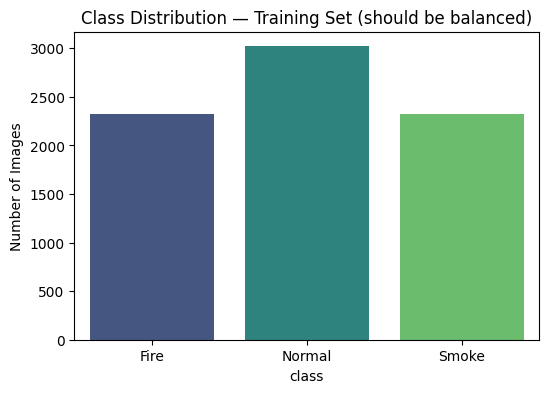

    class  count  proportion
0    Fire   2320    0.302872
1  Normal   3020    0.394256
2   Smoke   2320    0.302872


In [10]:
class_names = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
counts = {c: len(list((TRAIN_DIR/c).glob("*.jpg"))) for c in class_names}
print("Training image counts per class:", counts)

df_counts = pd.DataFrame(list(counts.items()), columns=["class", "count"])
plt.figure(figsize=(6,4))
sns.barplot(data=df_counts, x="class", y="count", palette="viridis")
plt.title("Class Distribution — Training Set (should be balanced)")
plt.ylabel("Number of Images")
plt.show()

total = df_counts["count"].sum()
df_counts["proportion"] = df_counts["count"] / total
print(df_counts)


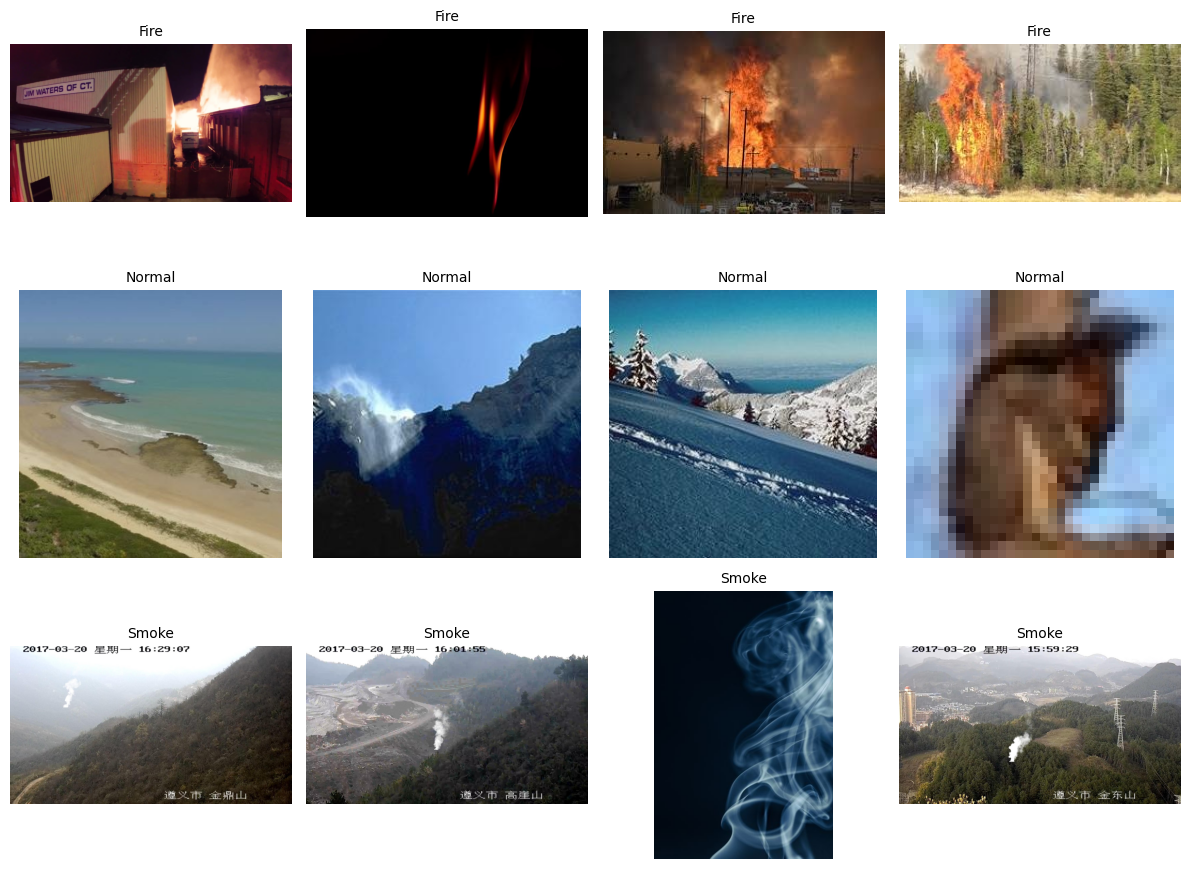

In [11]:
# Sample images grid
plt.figure(figsize=(12, 9))
i = 1
for c in class_names:
    files_in_class = list((TRAIN_DIR/c).glob("*.jpg"))[:4]
    for f in files_in_class:
        img = keras.utils.load_img(f)
        plt.subplot(len(class_names), 4, i)
        plt.imshow(img)
        plt.title(c, fontsize=10)
        plt.axis("off")
        i += 1
plt.tight_layout()
plt.show()


## 4️⃣ Data Pipeline (train / validation / test + augmentation)

The dataset already comes pre-split, so we load each folder separately instead of doing a manual 70/15/15 split like v2 did.
Data augmentation (flip, rotation, zoom, contrast) reduces overfitting given limited images.


In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED,
    label_mode="int"
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED,
    label_mode="int"
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED,
    label_mode="int", shuffle=False
)

class_names = train_ds.class_names
print("Classes (0, 1, 2 in this order):", class_names)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(200).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 7660 files belonging to 3 classes.
Found 959 files belonging to 3 classes.
Found 962 files belonging to 3 classes.
Classes (0, 1, 2 in this order): ['Fire', 'Normal', 'Smoke']
Train batches: 240
Val batches: 30
Test batches: 31


## 5️⃣ Baseline Model — CNN From Scratch
Built first as a comparison point. This lets you answer a common judges' question: *"Why not just train from scratch?"*


In [13]:
num_classes = len(class_names)
output_units = num_classes      # 3: fire, smoke, normal
output_activation = "softmax"
loss_fn = "sparse_categorical_crossentropy"

baseline_model = keras.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(output_units, activation=output_activation)
], name="baseline_cnn_from_scratch")

baseline_model.compile(optimizer="adam", loss=loss_fn, metrics=["accuracy"])
baseline_model.summary()


Model: "baseline_cnn_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
baseline_history = baseline_model.fit(train_ds, validation_data=val_ds, epochs=10)


Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 60s 107ms/step - accuracy: 0.8260 - loss: 0.4762 - val_accuracy: 0.9103 - val_loss: 0.2687
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.8984 - loss: 0.2747 - val_accuracy: 0.9208 - val_loss: 0.2367
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.9198 - loss: 0.2249 - val_accuracy: 0.9208 - val_loss: 0.2589
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.9362 - loss: 0.1835 - val_accuracy: 0.9312 - val_loss: 0.2905
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.9325 - loss: 0.1876 - val_accuracy: 0.9458 - val_loss: 0.1894
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.9448 - loss: 0.1635 - val_accuracy: 0.9312 - val_loss: 0.2459
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.9517 - loss: 0.1482 - val_accuracy: 0.9510 - val_loss: 0.1590
Epoch 8/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.9517 - loss: 0.1490 -

## 6️⃣ Main Model — Transfer Learning with MobileNetV2
This is the model you present as your final solution: a MobileNetV2 backbone pre-trained on ImageNet, with a custom 3-way classification head, fine-tuned on the fire/smoke/normal dataset.


In [15]:
base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet"
)
base_model.trainable = False  # freeze for phase 1

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(output_units, activation=output_activation)(x)
tl_model = keras.Model(inputs, outputs, name="mobilenetv2_transfer_learning")

tl_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss=loss_fn, metrics=["accuracy"])
tl_model.summary()


Model: "mobilenetv2_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
import tensorflow as tf
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history_phase1 = tl_model.fit(train_ds, validation_data=val_ds, epochs=12, callbacks=[early_stop])

Epoch 1/12
240/240 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.8978 - loss: 0.2735 - val_accuracy: 0.9614 - val_loss: 0.1196
Epoch 2/12
240/240 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.9580 - loss: 0.1253 - val_accuracy: 0.9718 - val_loss: 0.0922
Epoch 3/12
240/240 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.9632 - loss: 0.1109 - val_accuracy: 0.9708 - val_loss: 0.0940
Epoch 4/12
240/240 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.9681 - loss: 0.0931 - val_accuracy: 0.9771 - val_loss: 0.0693
Epoch 5/12
240/240 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.9709 - loss: 0.0853 - val_accuracy: 0.9802 - val_loss: 0.0648
Epoch 6/12
240/240 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.9723 - loss: 0.0818 - val_accuracy: 0.9802 - val_loss: 0.0585
Epoch 7/12
240/240 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.9728 - loss: 0.0798 - val_accuracy: 0.9781 - val_loss: 0.0725
Epoch 8/12
240/240 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.9755 - loss: 0.0740 - 

In [17]:
# Phase 2: fine-tune — unfreeze the top layers of MobileNetV2 with a low learning rate
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

tl_model.compile(optimizer=keras.optimizers.Adam(1e-5), loss=loss_fn, metrics=["accuracy"])

history_phase2 = tl_model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop])


Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - accuracy: 0.9394 - loss: 0.1740 - val_accuracy: 0.9760 - val_loss: 0.0777
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.9632 - loss: 0.1025 - val_accuracy: 0.9729 - val_loss: 0.0815
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - accuracy: 0.9685 - loss: 0.0874 - val_accuracy: 0.9760 - val_loss: 0.0752


## 7️⃣ Training Curves — Baseline vs Transfer Learning
Watch for: train & val accuracy should both climb well above ~33% (a 3-way random guess) and stay close together.

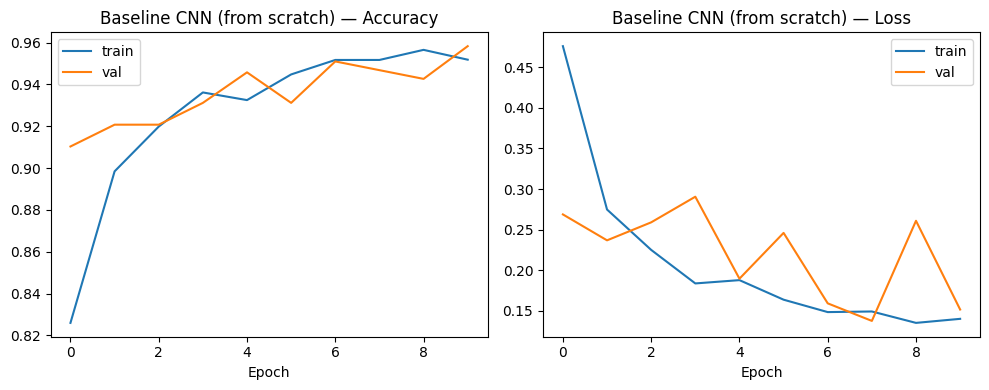

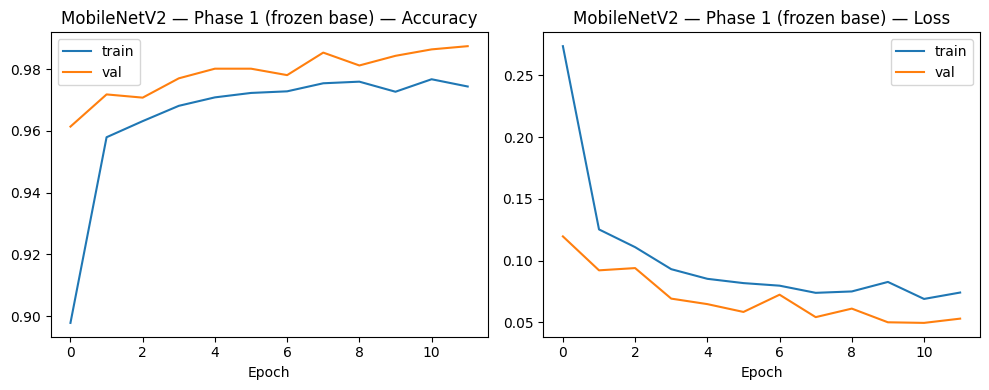

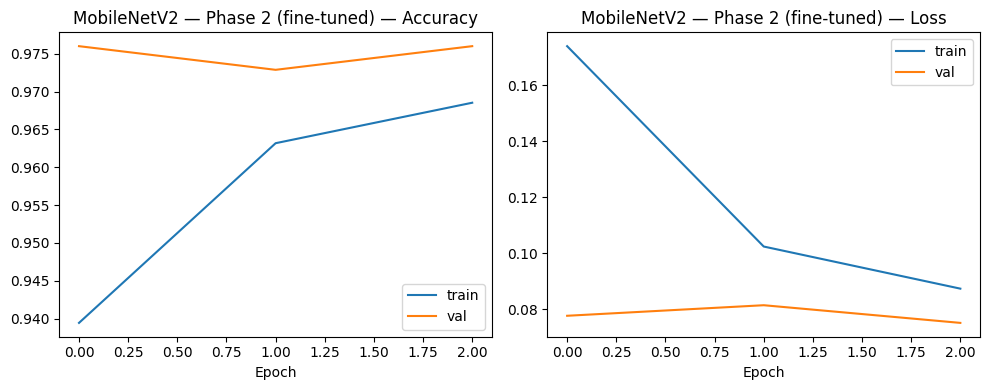

In [18]:
def plot_history(hist, title):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(hist.history["accuracy"], label="train")
    plt.plot(hist.history["val_accuracy"], label="val")
    plt.title(f"{title} — Accuracy"); plt.xlabel("Epoch"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.title(f"{title} — Loss"); plt.xlabel("Epoch"); plt.legend()
    plt.tight_layout(); plt.show()

plot_history(baseline_history, "Baseline CNN (from scratch)")
plot_history(history_phase1, "MobileNetV2 — Phase 1 (frozen base)")
plot_history(history_phase2, "MobileNetV2 — Phase 2 (fine-tuned)")


## 8️⃣ Evaluation on Test Set

In [19]:
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_ds)
tl_test_loss, tl_test_acc = tl_model.evaluate(test_ds)

print(f"Baseline CNN  -> Test Accuracy: {baseline_test_acc:.4f}")
print(f"MobileNetV2   -> Test Accuracy: {tl_test_acc:.4f}")

comparison = pd.DataFrame({
    "Model": ["Baseline CNN (scratch)", "MobileNetV2 (transfer learning)"],
    "Test Accuracy": [baseline_test_acc, tl_test_acc],
    "Test Loss": [baseline_test_loss, tl_test_loss]
})
comparison


31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.9543 - loss: 0.1448
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9813 - loss: 0.0820
Baseline CNN  -> Test Accuracy: 0.9543
MobileNetV2   -> Test Accuracy: 0.9813


,Model,Test Accuracy,Test Loss
0,Baseline CNN (scratch),0.954262,0.144767
1,MobileNetV2 (transfer learning),0.981289,0.081984


Prediction distribution (should NOT be all one class): [277 386 299]
True label distribution: [292 378 292]


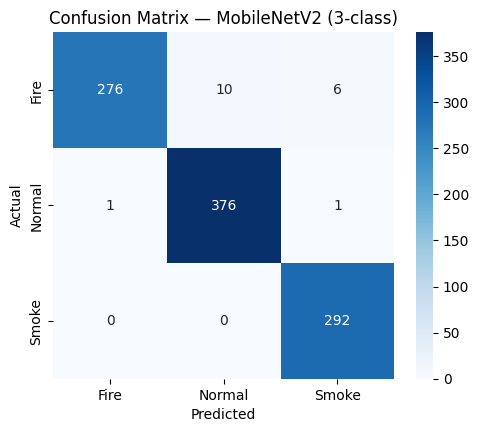

              precision    recall  f1-score   support

        Fire       1.00      0.95      0.97       292
      Normal       0.97      0.99      0.98       378
       Smoke       0.98      1.00      0.99       292

    accuracy                           0.98       962
   macro avg       0.98      0.98      0.98       962
weighted avg       0.98      0.98      0.98       962



In [20]:
# Confusion matrix + classification report + prediction-distribution sanity check
y_true, y_pred_probs = [], []
for images, labels in test_ds:
    preds = tl_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true).astype(int)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Prediction distribution (should NOT be all one class):", np.bincount(y_pred, minlength=num_classes))
print("True label distribution:", np.bincount(y_true, minlength=num_classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5.5,4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix — MobileNetV2 (3-class)")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


## 9️⃣ Save the Final Model

In [21]:
tl_model.save("fire_smoke_detector.keras")
print("Saved model as fire_smoke_detector.keras")
print("Class order (0, 1, 2):", class_names)


Saved model as fire_smoke_detector.keras
Class order (0, 1, 2): ['Fire', 'Normal', 'Smoke']


## 🔟 Frontend Demo — Gradio App (runs right inside Colab)
This gives you a live, shareable web link to demo in front of the judges — upload/drag an image and get fire / smoke / normal probabilities.


In [22]:
%%writefile app.py
import streamlit as st
import numpy as np
from tensorflow import keras
from PIL import Image

IMG_SIZE = (224, 224)
class_names = ['Fire', 'Normal', 'Smoke']  # apni actual class_names list yahan paste karein (order wahi jo training mein tha)

@st.cache_resource
def load_model():
    return keras.models.load_model("fire_smoke_detector.keras")

model = load_model()

st.set_page_config(page_title="Fire / Smoke / Normal Detection", page_icon="🔥")
st.title("🔥 Fire / Smoke / Normal Detection — Live Demo")
st.write("Upload an image to check if it shows fire, smoke, or a normal scene. Model: MobileNetV2 (Transfer Learning), fine-tuned on a balanced 3-class dataset.")

uploaded_file = st.file_uploader("Upload an image (CCTV / surveillance frame)", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    img = Image.open(uploaded_file).convert("RGB")
    st.image(img, caption="Uploaded image", use_container_width=True)

    resized = img.resize(IMG_SIZE)
    arr = keras.utils.img_to_array(resized)
    arr = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]

    result = {class_names[i]: float(probs[i]) for i in range(len(class_names))}
    sorted_result = dict(sorted(result.items(), key=lambda x: x[1], reverse=True))

    st.subheader("Prediction")
    for label, prob in sorted_result.items():
        st.write(f"**{label}**: {prob*100:.1f}%")
        st.progress(prob)

Overwriting app.py


In [23]:
!pip install -q streamlit pyngrok

In [24]:
!pip install -q pyngrok
from pyngrok import ngrok

# Free ngrok account bana kar apna authtoken yahan daalein: https://dashboard.ngrok.com/get-started/your-authtoken
# Replace "YOUR_AUTHTOKEN_HERE" with your actual ngrok authtoken obtained from the ngrok dashboard.
ngrok.set_auth_token("3HB7T53W5OoFA6aJLVTjiSlkNbq_6BD3p6HN5TrJt1cEPdmim")

public_url = ngrok.connect(8501)
print("App is live at:", public_url)

!streamlit run app.py &>/content/logs.txt &

App is live at: NgrokTunnel: "https://dust-hacksaw-dander.ngrok-free.dev" -> "http://localhost:8501"


In [25]:
!pip install -q streamlit pyngrok